In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [2]:
import stableemrifisher
stableemrifisher.__file__
from tqdm import tqdm
from stableemrifisher.fisher.fisher import StableEMRIFisher


startup


# Set Up

In [3]:
# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 0.25   # Total time

# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True
}

waveform_class = FastKerrEccentricEquatorialFlux
waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                             amplitude_kwargs=amplitude_kwargs,
                             Ylm_kwargs=Ylm_kwargs,
                             sum_kwargs=sum_kwargs,
                             use_gpu=use_gpu)

 
#waveform generator setup
waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(frame='detector')

waveform_gen = GenerateEMRIWaveform(
    waveform_class, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

In [ ]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [ ]:
from lisatools.sensitivity import get_sensitivity, CornishLISASens


In [ ]:
# from stableemrifisher.noise import sensitivity_LWA

sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable', noise_model=get_sensitivity, noise_kwargs={'sens_fn':CornishLISASens, 'return_type': 'PSD'}, channels=["A"])


In [ ]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [ ]:
waveform = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,  T=T, dt=dt)

In [ ]:
hf = gwf.freq_wave(waveform)
np.sqrt(gwf.inner(hf,hf))

array(107.43946161)

In [ ]:
sef.channels

['A']

# Computing Fisher 

T:  0.25 dt:  10
Body is not plunging, Fisher should be stable.


wave ndim: 2
Computing SNR for parameters: (1000000.0, 30.0, 0.7, 7.5, 0.4, 1.0, 0.5, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.0, 0.5)
Waveform Generated. SNR: 107.4394616101364
calculating stable deltas...
Gamma_ii for m1: 592.8246153666494
Gamma_ii for m1: 592.8246153555673
Gamma_ii for m1: 592.8246153541139
Gamma_ii for m1: 592.8246154215007
Gamma_ii for m1: 592.8246154226514
Gamma_ii for m1: 592.8246132316539
Gamma_ii for m1: 592.8245937948226
Gamma_ii for m1: 592.8246920518216
[1.8693689444083802e-11, 2.451606252154343e-12, 1.1367061089931033e-10, 1.9411106446681274e-12, 3.695861257105813e-09, 3.278681668055054e-08, 1.6574376925376608e-07]
3


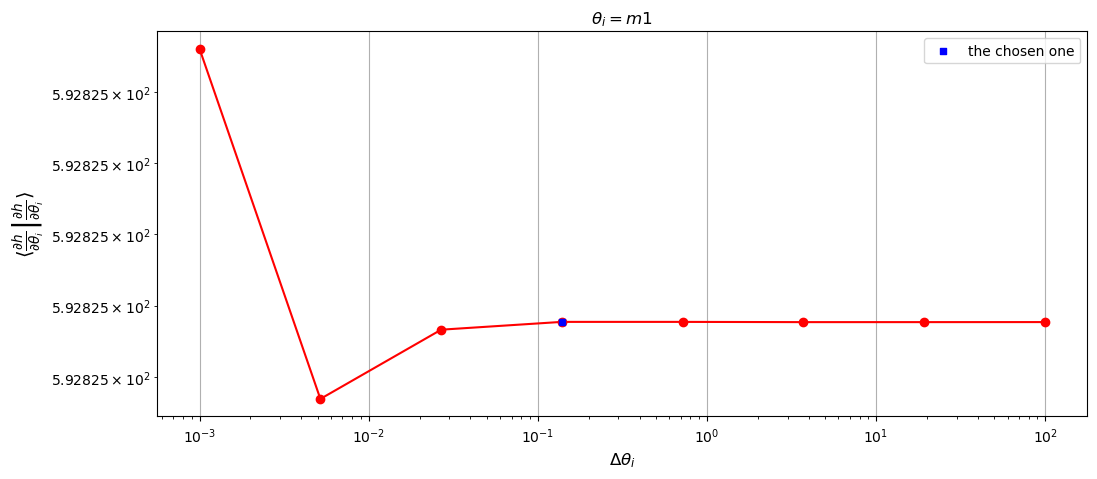

Gamma_ii for m2: 21227273818.435528
Gamma_ii for m2: 21227273818.43465
Gamma_ii for m2: 21227273813.319714
Gamma_ii for m2: 21227273766.620632
Gamma_ii for m2: 21227273899.844357
Gamma_ii for m2: 21227273384.163345
Gamma_ii for m2: 21227266988.09415
Gamma_ii for m2: 21227260563.64509
[4.133269201680511e-14, 2.4096060914820605e-10, 2.1999566187501476e-09, 6.276063756176021e-09, 2.429332311632054e-08, 3.0131383368292764e-07, 3.026508787172594e-07]
0


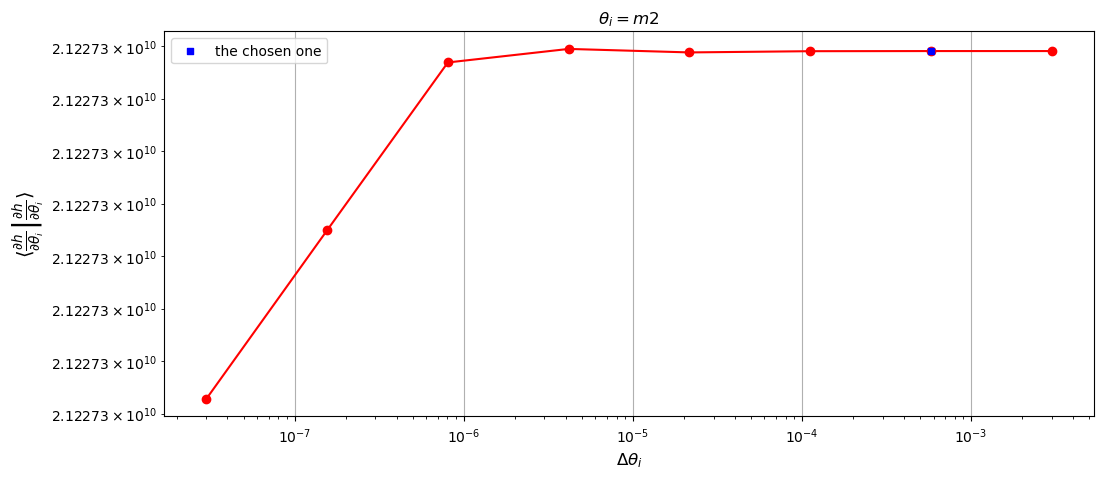

Gamma_ii for a: 23167882053073.094
Gamma_ii for a: 23167889371352.16
Gamma_ii for a: 23167871207049.7
Gamma_ii for a: 23167848060874.188
Gamma_ii for a: 23166655352788.316
Gamma_ii for a: 23166738778375.04
Gamma_ii for a: 23220136117295.93
Gamma_ii for a: 23303158479100.51
[3.158802663938622e-07, 7.840298445465428e-07, 9.99064541985147e-07, 5.1483827410914565e-05, 3.6010932535972545e-06, 0.0022996135186785865, 0.003562708543523867]
0


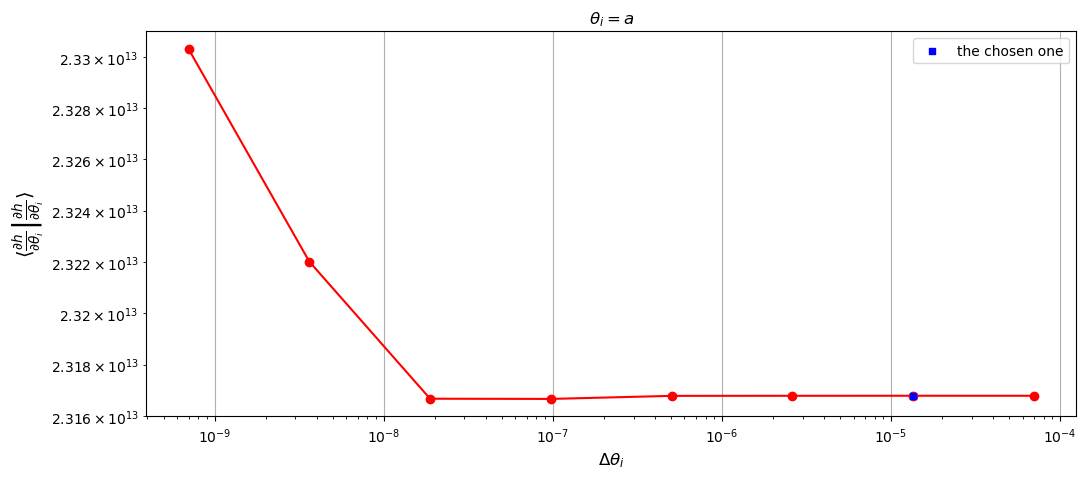

Gamma_ii for p0: 28486664707204.785
Gamma_ii for p0: 28486664571205.395
Gamma_ii for p0: 28486665476399.133
Gamma_ii for p0: 28486677884669.973
Gamma_ii for p0: 28486668891134.305
Gamma_ii for p0: 28486796307117.797
Gamma_ii for p0: 28486561108887.14
Gamma_ii for p0: 28479257143610.965
[4.774142310871647e-09, 3.1776051115255746e-08, 4.355815335884156e-07, 3.157103311144864e-07, 4.472808458996526e-06, 8.25646274947781e-06, 0.00025646614444135363]
0


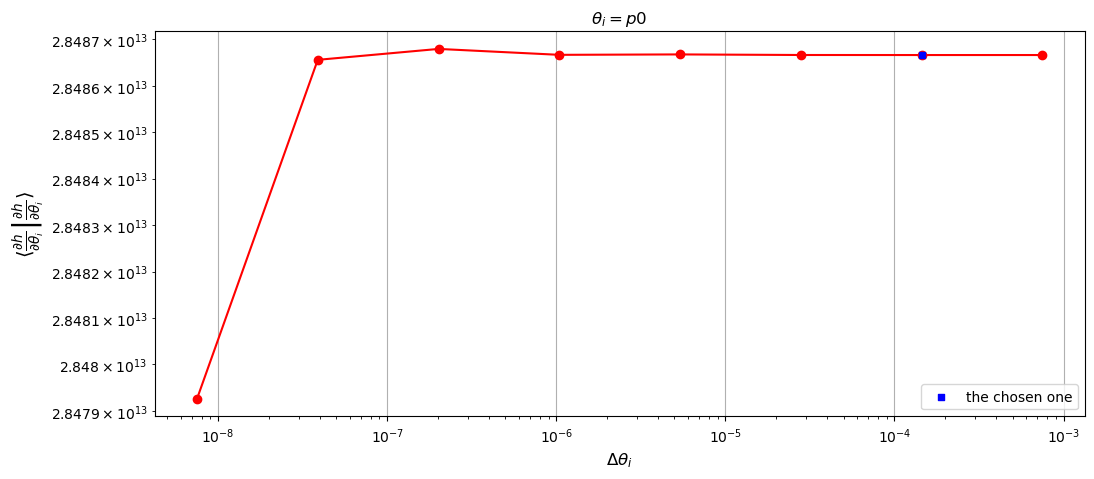

Gamma_ii for e0: 172687134259449.22
Gamma_ii for e0: 172687138288579.03
Gamma_ii for e0: 172687141139206.44
Gamma_ii for e0: 172687166662163.34
Gamma_ii for e0: 172684739885720.5
Gamma_ii for e0: 172699414658532.9
Gamma_ii for e0: 172555707601094.12
Gamma_ii for e0: 172762405421732.94
[2.333196237097221e-08, 1.6507467709781902e-08, 1.477988052012102e-07, 1.4053218856800808e-05, 8.497291575319872e-05, 0.0008328154393536273, 0.0011964282398953597]
1


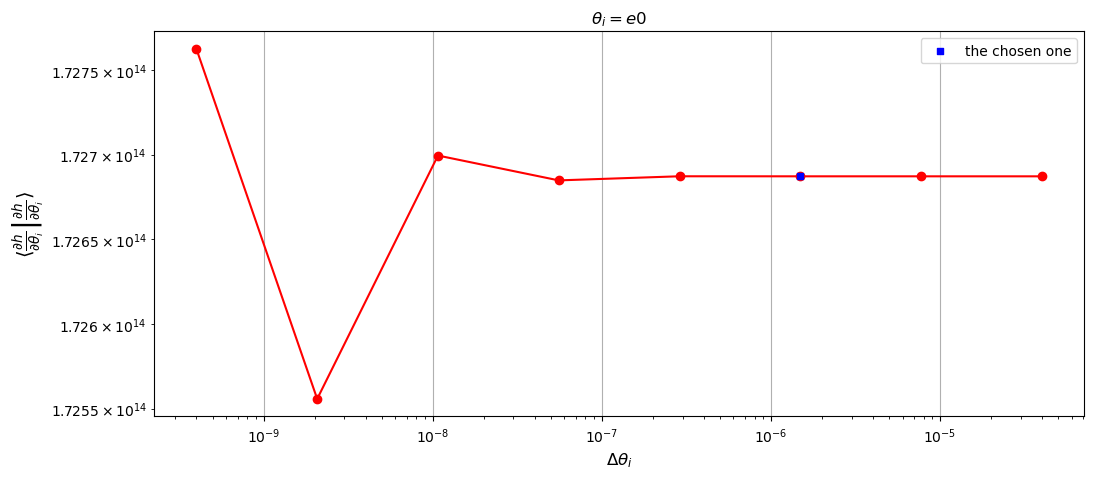

stable deltas: {'m1': 0.13894954943731375, 'm2': 0.0005792093186649751, 'a': 1.351488410218275e-05, 'p0': 0.0001448023296662437, 'e0': 1.4910374881259754e-06}
Time taken to compute stable deltas is 352.3814458847046 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 43.43171310424805 seconds


In [11]:
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
# NOTE: leaving off only intrinsic params
param_names = ['m1','m2','a','p0','e0']
der_order = 4
Ndelta = 8
stability_plot = True
# using default delta range first by SEF
Fisher = sef(*pars_list, param_names = param_names, 
             T = T, dt = dt, 
             der_order = der_order, 
             Ndelta = Ndelta, 
             stability_plot = stability_plot,
            #  delta_range = delta_range,
            live_dangerously = False)

In [12]:
np.linalg.eigvals(Fisher)

array([2.16163024e+14, 8.05812362e+12, 1.41763574e+11, 3.41309351e-05,
       1.08382128e+07])

In [13]:
# CHAIN RULE FOR FISHER
J_mx = np.eye(5)
J_mx[0, 0] = m1 * np.log(10) 
J_mx[1, 1] = m2 * np.log(10) 
# J_mx[6, 6] = -1/np.sin(qS)

Fisher_scaled = J_mx.T @ Fisher @ J_mx

(<Figure size 2000x2000 with 15 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

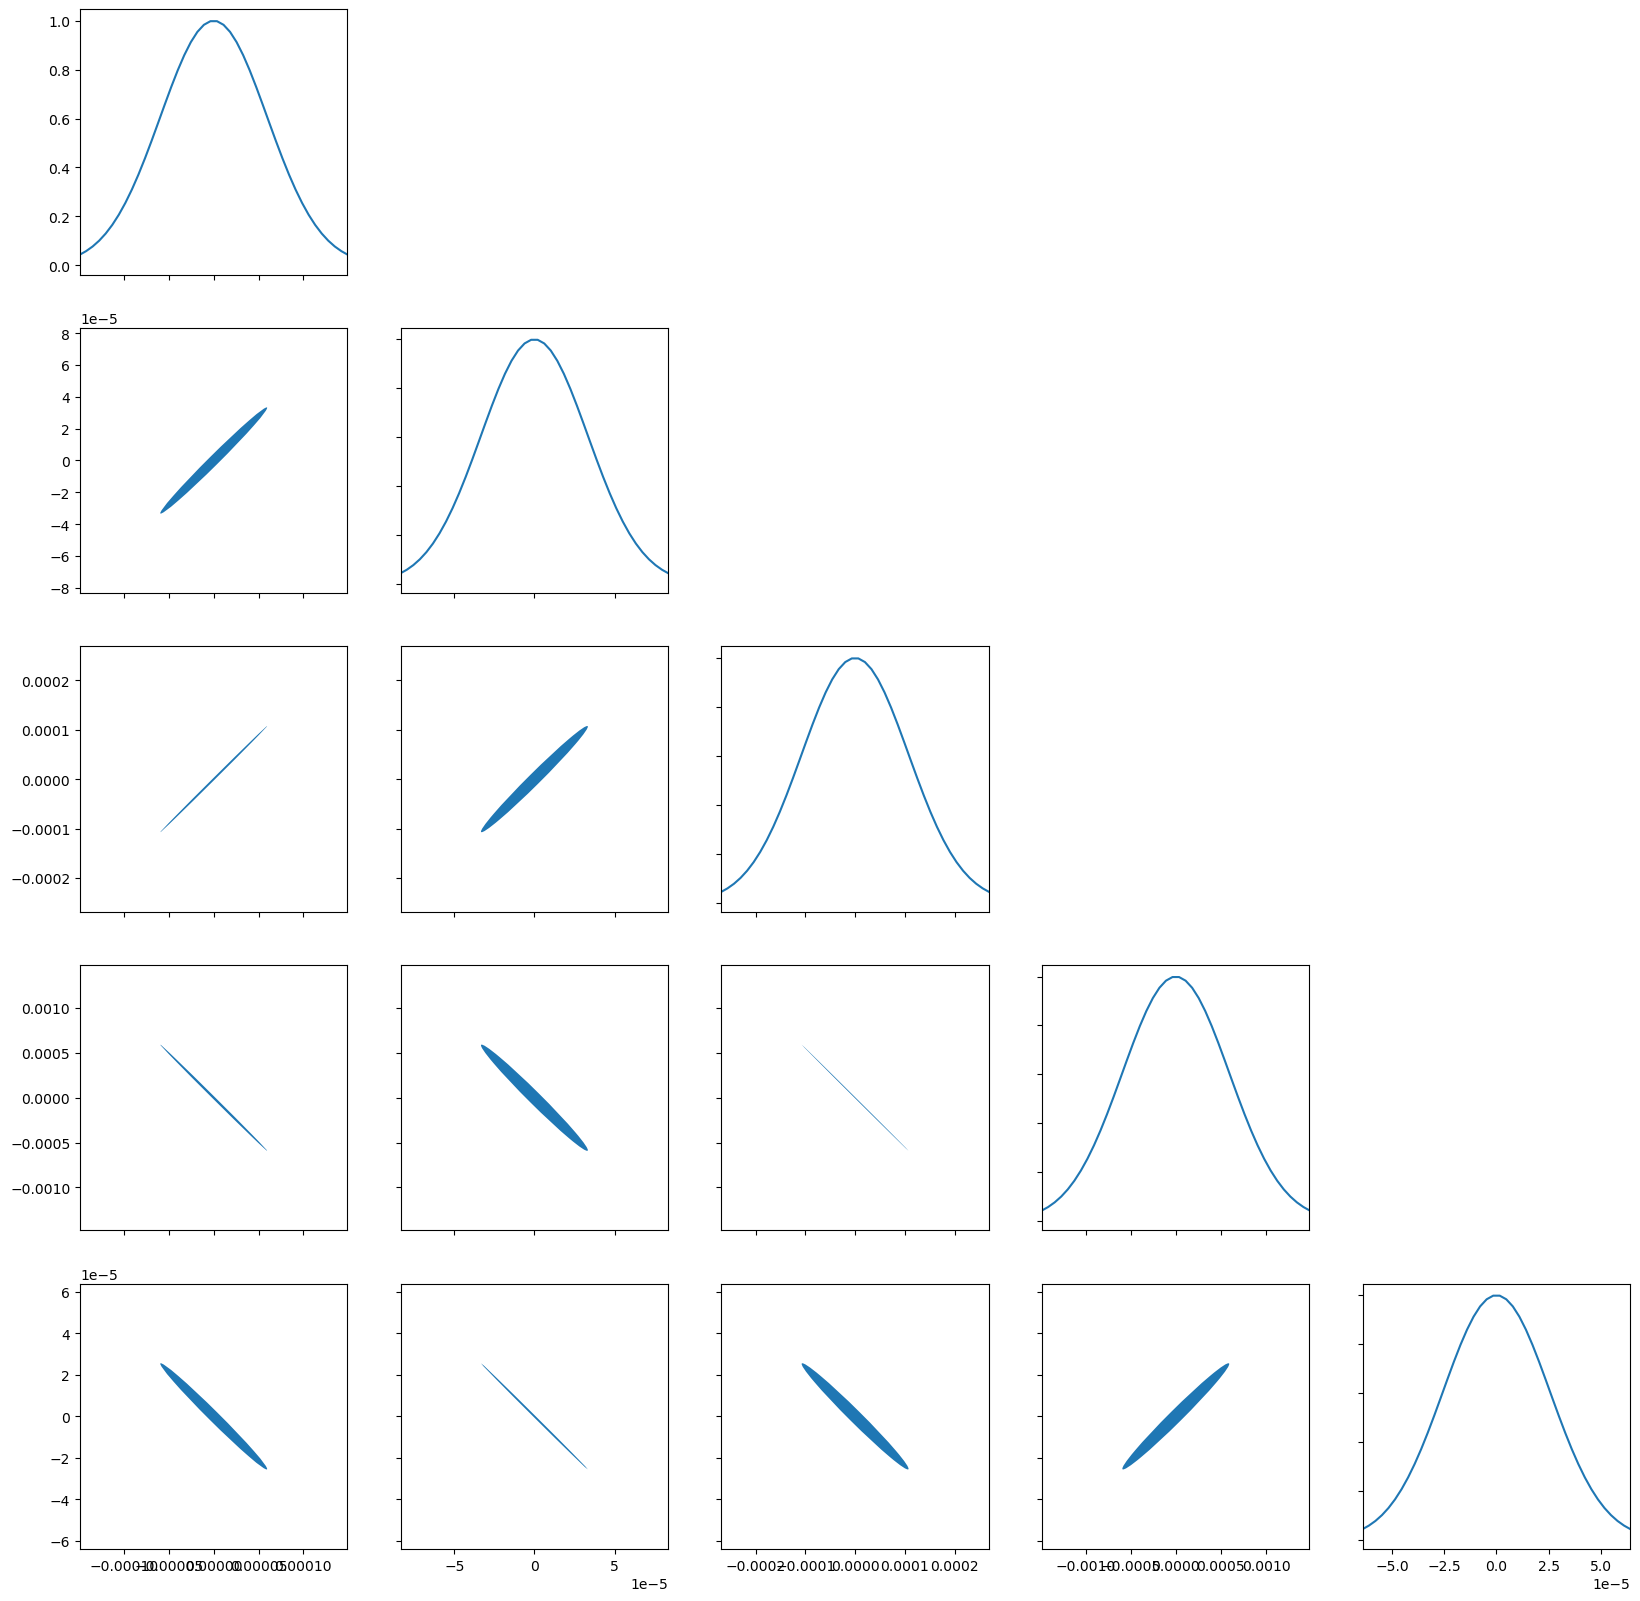

In [14]:
from stableemrifisher.plot import CovEllipsePlot

CovEllipsePlot(np.linalg.inv(Fisher_scaled))

In [15]:
cov = np.linalg.inv(Fisher_scaled)
cov

array([[ 3.55036939e-09,  1.97058225e-09,  6.39496565e-09,
        -3.52707169e-08, -1.51284561e-09],
       [ 1.97058225e-09,  1.11300335e-09,  3.53827252e-09,
        -1.94948421e-08, -8.55047433e-10],
       [ 6.39496565e-09,  3.53827252e-09,  1.15264063e-08,
        -6.35798533e-08, -2.71543769e-09],
       [-3.52707169e-08, -1.94948421e-08, -6.35798533e-08,
         3.50744571e-07,  1.49625875e-08],
       [-1.51284561e-09, -8.55047433e-10, -2.71543769e-09,
         1.49625875e-08,  6.57285866e-10]])

In [33]:
def loglike(params):
    logm1, logm2, a, p0, e0 = params
    m1 = 10**logm1
    m2 = 10**logm2

    htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
            
    res = waveform - htemp
    res_f = gwf.freq_wave(res)
    inner_res = gwf.inner(res_f, res_f)
    log_like = -0.5 * inner_res.get()
    return log_like

In [34]:
param_mean - 4*param_std

7.4976310523161365

In [49]:
from stableemrifisher.utils import inner_product
def likelihood(h_inj, h_temp):
    if len(h_inj) == 1:
        delta = h_inj - h_temp
        delta = [delta.real, -delta.imag]
    else:
        delta = [h_inj[i] - h_temp[i] for i in range(len(h_inj))]
    
    PSD = lambda f: get_sensitivity(f, sens_fn=CornishLISASens, return_type='PSD')
    return np.exp(-0.5 * inner_product(delta, delta, PSD = PSD, dt = dt, use_gpu=use_gpu))


In [47]:
# plot of fisher vs loglike 
from scipy.stats import norm
param_idx = 0
param_std = np.sqrt(cov[param_idx, param_idx])
param_mean = np.log10(pars_list[param_idx])
x = np.linspace(param_mean - 2*param_std, param_mean + 2*param_std, 10)
loglike_vals = []


In [50]:
for val in x:
    htemp = waveform_gen(10**val, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
    calc_like = likelihood(waveform, htemp)
    loglike_vals.append(np.log(calc_like))


TypeError: len() of unsized object

In [16]:
np.diag(cov)

array([3.55036939e-09, 1.11300335e-09, 1.15264063e-08, 3.50744571e-07,
       6.57285866e-10])

In [17]:
sigmas = np.sqrt(np.diag(cov))
sigmas

array([5.95849762e-05, 3.33617048e-05, 1.07361102e-04, 5.92236921e-04,
       2.56375870e-05])

In [ ]:
log_m1 = np.log10(m1)
log_m2 = np.log10(m2)  
# cos_qS = np.cos(qS)

transformed_params = [log_m1, log_m2, a, p0, e0]
transformed_names = ['log_m1', 'log_m2', 'a', 'p0', 'e0']


In [19]:
for i, name in enumerate(transformed_names):
    param_value = transformed_params[i]
    result_low = param_value - sigmas[i]
    result_high = param_value + sigmas[i] 
    prior_low = param_value - 3*sigmas[i]
    prior_high = param_value + 3*sigmas[i]
    
    print(f"=== {name}: {param_value} +/- {sigmas[i]}")
    print(f"3-sigma prior range: [{prior_low:.10e}, {prior_high:.10e}]")

=== log_m1: 6.0 +/- 5.958497620591233e-05
3-sigma prior range: [5.9998212451e+00, 6.0001787549e+00]
=== log_m2: 1.4771212547196624 +/- 3.336170479791738e-05
3-sigma prior range: [1.4770211696e+00, 1.4772213398e+00]
=== a: 0.7 +/- 0.00010736110231940298
3-sigma prior range: [6.9967791669e-01, 7.0032208331e-01]
=== p0: 7.5 +/- 0.0005922369209657856
3-sigma prior range: [7.4982232892e+00, 7.5017767108e+00]
=== e0: 0.4 +/- 2.563758697034008e-05
3-sigma prior range: [3.9992308724e-01, 4.0007691276e-01]


In [33]:
for i, name in enumerate(transformed_names):
    param_value = transformed_params[i]
    result_low = param_value - sigmas[i]
    result_high = param_value + sigmas[i] 
    prior_low = param_value - 10*sigmas[i]
    prior_high = param_value + 10*sigmas[i]
    
    print(f"=== {name}: {param_value} +/- {sigmas[i]}")
    print(f"10-sigma prior range: [{prior_low:.10e}, {prior_high:.10e}]")

=== log_m1: 6.0 +/- 5.958497620591233e-05
10-sigma prior range: [5.9994041502e+00, 6.0005958498e+00]
=== log_m2: 1.4771212547196624 +/- 3.336170479791738e-05
10-sigma prior range: [1.4767876377e+00, 1.4774548718e+00]
=== a: 0.7 +/- 0.00010736110231940298
10-sigma prior range: [6.9892638898e-01, 7.0107361102e-01]
=== p0: 7.5 +/- 0.0005922369209657856
10-sigma prior range: [7.4940776308e+00, 7.5059223692e+00]
=== e0: 0.4 +/- 2.563758697034008e-05
10-sigma prior range: [3.9974362413e-01, 4.0025637587e-01]


In [21]:
for i, name in enumerate(transformed_names):
    param_value = transformed_params[i]
    result_low = param_value - sigmas[i]
    result_high = param_value + sigmas[i] 
    prior_low = param_value - 5*sigmas[i]
    prior_high = param_value + 5*sigmas[i]
    
    print(f"=== {name}: {param_value} +/- {sigmas[i]}")
    print(f"5-sigma prior range: [{prior_low:.10e}, {prior_high:.10e}]")

=== log_m1: 6.0 +/- 5.958497620591233e-05
5-sigma prior range: [5.9997020751e+00, 6.0002979249e+00]
=== log_m2: 1.4771212547196624 +/- 3.336170479791738e-05
5-sigma prior range: [1.4769544462e+00, 1.4772880632e+00]
=== a: 0.7 +/- 0.00010736110231940298
5-sigma prior range: [6.9946319449e-01, 7.0053680551e-01]
=== p0: 7.5 +/- 0.0005922369209657856
5-sigma prior range: [7.4970388154e+00, 7.5029611846e+00]
=== e0: 0.4 +/- 2.563758697034008e-05
5-sigma prior range: [3.9987181207e-01, 4.0012818793e-01]


In [22]:
for i, name in enumerate(transformed_names):
    param_value = transformed_params[i]
    result_low = param_value - sigmas[i]
    result_high = param_value + sigmas[i] 
    prior_low = param_value - 1*sigmas[i]
    prior_high = param_value + 1*sigmas[i]
    
    print(f"=== {name}: {param_value} +/- {sigmas[i]}")
    print(f"1-sigma prior range: [{prior_low:.10e}, {prior_high:.10e}]")

=== log_m1: 6.0 +/- 5.958497620591233e-05
1-sigma prior range: [5.9999404150e+00, 6.0000595850e+00]
=== log_m2: 1.4771212547196624 +/- 3.336170479791738e-05
1-sigma prior range: [1.4770878930e+00, 1.4771546164e+00]
=== a: 0.7 +/- 0.00010736110231940298
1-sigma prior range: [6.9989263890e-01, 7.0010736110e-01]
=== p0: 7.5 +/- 0.0005922369209657856
1-sigma prior range: [7.4994077631e+00, 7.5005922369e+00]
=== e0: 0.4 +/- 2.563758697034008e-05
1-sigma prior range: [3.9997436241e-01, 4.0002563759e-01]


In [23]:
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

In [24]:
import pickle
with open('cov_matrix_intrinsic_new.pkl', 'wb') as f:
    pickle.dump(cov, f)